# Module 3: Fixation

This module has no equivalent in the original assignment. It was added to model
the fixation step that follows impact and spreading.

For water-based latex inks, fixation works like this:

1. Water evaporates from the spread ink film, driven by the heated platen.
2. The latex particle volume fraction phi increases as the volume drops.
3. When phi exceeds close-packing (~0.64), capillary forces drive the
   latex particles together and the film solidifies.

The dot size from Module 2 sets the film geometry here.

Note on the evaporation model: the mass transfer coefficient h_m = 0.1 m/s
is a back-of-envelope estimate for light forced airflow
(h_m ~ D_wv / delta ~ 2.6e-5 / 3e-4 ~ 0.087 m/s). It is not from a paper.
The model gives physically plausible drying times (50-300 ms at 60-100 C)
but should not be used for precise quantitative predictions without
calibrating h_m against real printer conditions.


In [1]:
import sys
from pathlib import Path

# Walk up from current directory until we find the project root
# (the folder that contains src/). Works regardless of where
# Cursor or Jupyter launches from.
_search = Path.cwd()
while _search != _search.parent:
    if (_search / 'src').exists():
        break
    _search = _search.parent

ROOT    = _search
SRC     = ROOT / 'src'
FIGURES = ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f'ROOT   : {ROOT}')
print(f'SRC    : {SRC}')
print(f'FIGURES: {FIGURES}')

import numpy as np
import matplotlib.pyplot as plt
from ink_properties import INKS, SUBSTRATES
from flight import simulate_flight
from impact import dot_diameter
from fixation import (
    DryingState, simulate_drying,
    drying_time_vs_temperature, drying_time_vs_dot_size,
    fixation_operating_window,
    plot_drying_curve, plot_drying_vs_temperature, plot_operating_window,
    saturation_pressure
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

ROOT   : c:\
SRC    : c:\src
FIGURES: c:\results\figures


## 3.1 Full pipeline: flight into impact into fixation

In [2]:
ink = INKS['water_based_mid_visc']
sub = SUBSTRATES['coated_paper']
d   = 30e-6
v0  = 8.0

flight  = simulate_flight(ink, d=d, v0=v0, angle_deg=90.0, y0=1e-3)
v_imp   = flight['v_impact']
D_dot   = dot_diameter(ink, sub, d, v_imp)
h0      = (2.0 * d**3) / (3.0 * D_dot**2)

ds  = DryingState(D_dot=D_dot, h0=h0, phi0=ink.phi0, T_K=sub.T_platen, RH=0.50)
res = simulate_drying(ds)

print(f"Jetting speed  : v0    = {v0:.1f} m/s")
print(f"Impact speed   : v_imp = {v_imp:.3f} m/s")
print(f"Dot diameter   : D_dot = {D_dot*1e6:.1f} um")
print(f"Film thickness : h0    = {h0*1e9:.1f} nm")
print(f"Platen temp    : T     = {sub.T_platen-273.15:.0f} C")
print(f"Drying time    : t_dry = {res['t_dry']*1e3:.1f} ms")

Jetting speed  : v0    = 8.0 m/s
Impact speed   : v_imp = 7.314 m/s
Dot diameter   : D_dot = 82.6 um
Film thickness : h0    = 2636.8 nm
Platen temp    : T     = 60 C
Drying time    : t_dry = 190.5 ms


## 3.2 Drying curve: phi(t)

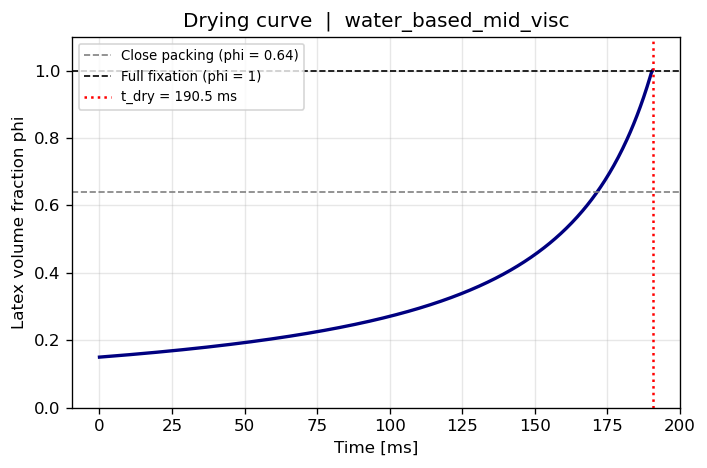

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_drying_curve(res, ink, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / '03_drying_curve.png', bbox_inches='tight')
plt.show()

## 3.3 Antoine equation: saturation pressure vs. temperature

Higher temperature means higher saturation vapour pressure and a bigger driving
force for evaporation. This is why the heated platen speeds up drying.

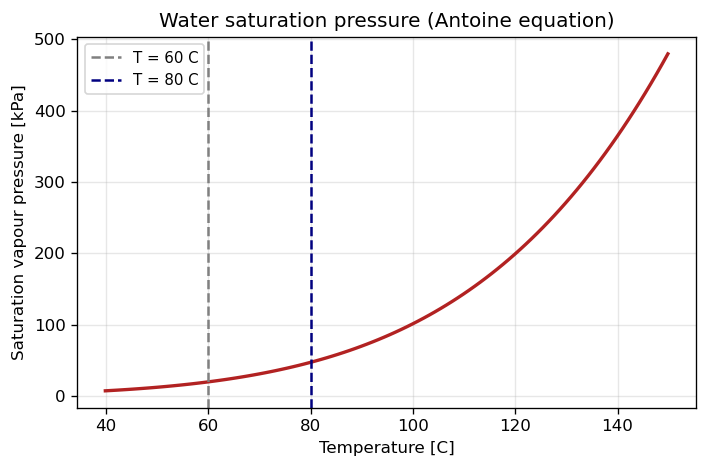

In [4]:
T_range = np.linspace(313, 423, 100)
P_sat   = [saturation_pressure(T) / 1000 for T in T_range]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_range - 273.15, P_sat, color='firebrick', linewidth=2)
ax.axvline(60, color='gray', linestyle='--', label='T = 60 C')
ax.axvline(80, color='navy', linestyle='--', label='T = 80 C')
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Saturation vapour pressure [kPa]')
ax.set_title('Water saturation pressure (Antoine equation)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '03_antoine.png', bbox_inches='tight')
plt.show()

## 3.4 Drying time vs. platen temperature

The main design curve for a fixation unit.

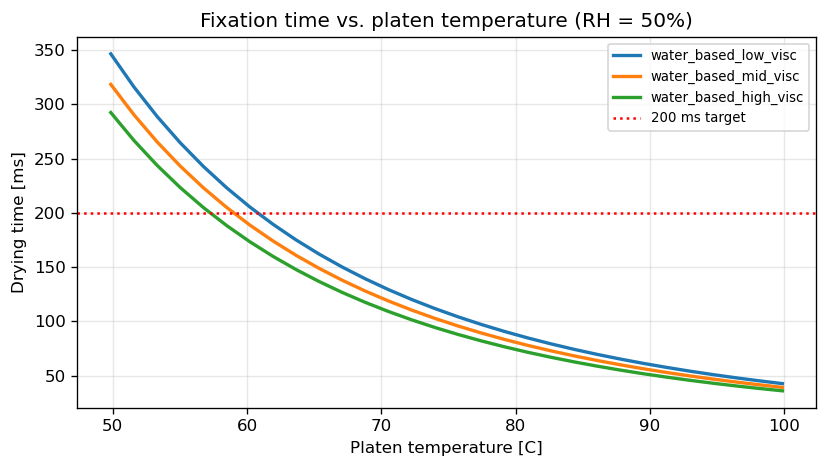

In [5]:
T_range = np.linspace(323, 373, 30)
fig, ax = plt.subplots(figsize=(7, 4))

for name, ink_ in INKS.items():
    if 'water' in name:
        flight_ = simulate_flight(ink_, d=d, v0=v0, angle_deg=90.0)
        D_dot_  = dot_diameter(ink_, sub, d, flight_['v_impact'])
        h0_     = (2.0 * d**3) / (3.0 * D_dot_**2)
        t_drys  = drying_time_vs_temperature(ink_, sub, D_dot_, h0_, T_range)
        ax.plot(T_range - 273.15, t_drys * 1e3, linewidth=2, label=name)

ax.axhline(200, color='red', linestyle=':', linewidth=1.5, label='200 ms target')
ax.set_xlabel('Platen temperature [C]')
ax.set_ylabel('Drying time [ms]')
ax.set_title('Fixation time vs. platen temperature (RH = 50%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '03_drying_vs_temp.png', bbox_inches='tight')
plt.show()

## 3.5 Fixation operating window

Which combinations of platen temperature and ambient humidity achieve
a drying time below 200 ms?

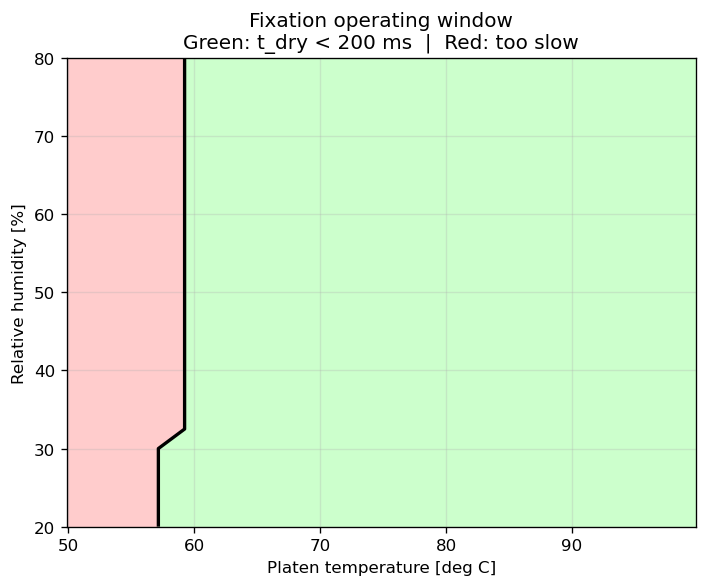

Fraction of (T, RH) space meeting t_dry < 200 ms: 81%


In [6]:
ink    = INKS['water_based_mid_visc']
v_imp  = simulate_flight(ink, d=d, v0=v0, angle_deg=90.0)['v_impact']
D_dot  = dot_diameter(ink, sub, d, v_imp)
h0     = (2.0 * d**3) / (3.0 * D_dot**2)

T_range  = np.linspace(323, 373, 25)
RH_range = np.linspace(0.20, 0.80, 25)
t_limit  = 0.200

window = fixation_operating_window(ink, D_dot, h0, T_range, RH_range, t_limit)

fig, ax = plt.subplots(figsize=(6, 5))
plot_operating_window(T_range, RH_range, window, t_limit, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / '03_operating_window.png', bbox_inches='tight')
plt.show()

print(f"Fraction of (T, RH) space meeting t_dry < {t_limit*1e3:.0f} ms: {window.mean()*100:.0f}%")

## 3.6 Dot size affects drying time

Larger dots from spreading have more contact area but thinner films.
The area effect wins, so larger dots dry slightly faster.

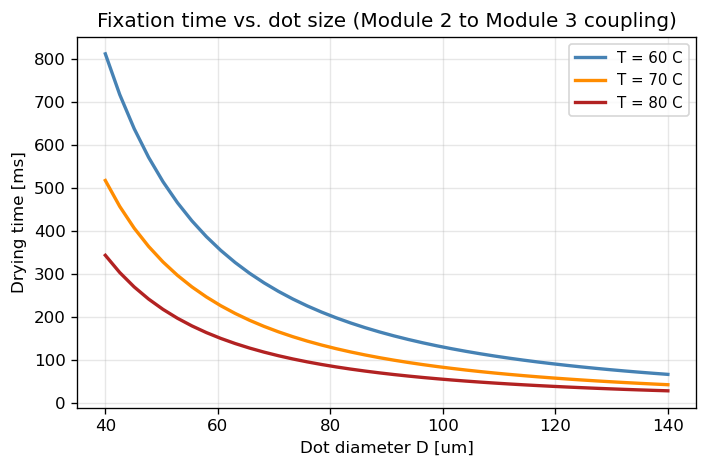

In [7]:
ink     = INKS['water_based_mid_visc']
D_range = np.linspace(40e-6, 140e-6, 40)
T_vals  = [333.15, 343.15, 353.15]
colors  = ['steelblue', 'darkorange', 'firebrick']

fig, ax = plt.subplots(figsize=(6, 4))
for T, col in zip(T_vals, colors):
    t_drys = drying_time_vs_dot_size(ink, sub, D_range, T_K=T)
    ax.plot(D_range * 1e6, t_drys * 1e3, color=col, linewidth=2,
            label=f'T = {T-273.15:.0f} C')

ax.set_xlabel('Dot diameter D [um]')
ax.set_ylabel('Drying time [ms]')
ax.set_title('Fixation time vs. dot size (Module 2 to Module 3 coupling)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / '03_drying_vs_dot_size.png', bbox_inches='tight')
plt.show()